# 10 · Wine Quality — Capstone: Red vs White & Synthesis

## Part 10 — Capstone: Red vs White, and a Synthesis

We close with a **contrast** that crystallises the whole practice. Using the *same chemistry features*,
we now predict a *different target* — is this wine **red or white**? Part 2 hinted it would be easy
(the types nearly separate in PCA). It is **near-perfect**. Holding the data fixed and swapping only
the target — from hard (`quality`, QWK ≈ 0.56) to trivial (`type`, AUC ≈ 1.0) — isolates the real
lesson of all ten notebooks: **difficulty lives in the target's relationship to the features, not in
the model.**

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import modeling as M
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
d = data.dedup(data.clean())
X = d[data.NUMERIC]; y = (d.wine_type == "white").astype(int)   # 1 = white
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, stratify=y, random_state=0)
print("predicting red(%d) vs white(%d) from 11 chemistry features" % ((y==0).sum(), (y==1).sum()))

setup ok | numpy 2.1.3 | pandas 2.3.3


predicting red(1359) vs white(3961) from 11 chemistry features


### 1. The near-perfect classifier

LightGBM separates red from white at **~99.5% accuracy / AUC ≈ 0.9996** — only a handful of wines are
misclassified, and those are the genuinely ambiguous bottles (a red with white-like chemistry). Recall
that `quality`, with the identical inputs, topped out around QWK 0.56.

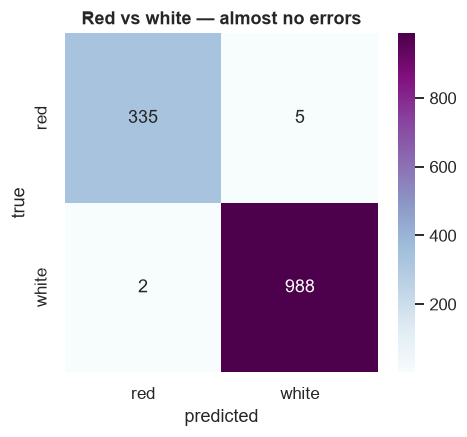

accuracy 0.9947 | ROC-AUC 0.99959 | 5-fold acc 0.9944 | errors: 7/1330


In [2]:
m = LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, random_state=0, verbose=-1, n_jobs=-1).fit(Xtr, ytr)
pred = m.predict(Xte); proba = m.predict_proba(Xte)[:, 1]
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuPu", xticklabels=["red","white"], yticklabels=["red","white"], ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Red vs white — almost no errors")
eda.savefig(fig, "p10_redwhite_cm.png"); plt.show()
print("accuracy %.4f | ROC-AUC %.5f | 5-fold acc %.4f | errors: %d/%d" %
      (accuracy_score(yte, pred), roc_auc_score(yte, proba), cross_val_score(m, X, y, cv=5).mean(), (pred != yte).sum(), len(yte)))

### 2. What separates them — the chemistry of colour

The separators are exactly the markers Part 1 flagged: **total SO₂** and **chlorides** (whites are
preserved with more sulfur; reds are saltier), then **density** and **sulphates**. Unlike quality,
red/white is an *objective, chemically-determined* label — so a few features nail it.

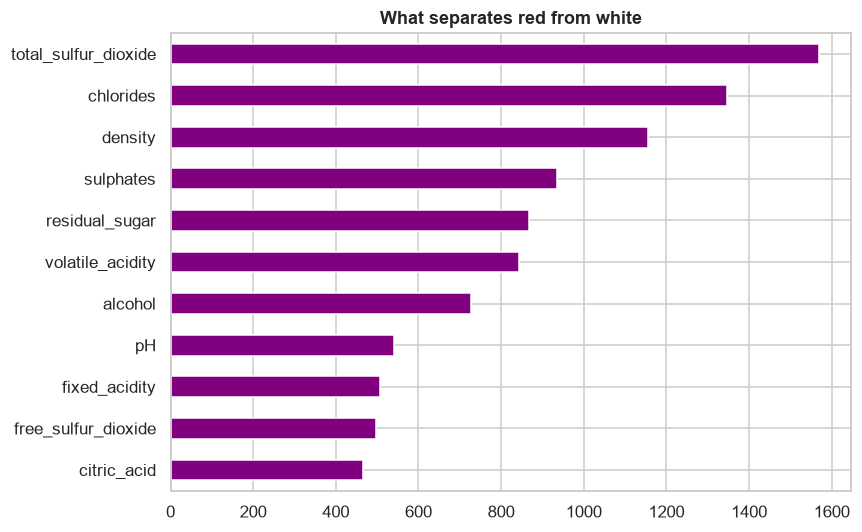

top separators: ['total_sulfur_dioxide', 'chlorides', 'density', 'sulphates']


In [3]:
imp = pd.Series(m.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5)); imp.plot.barh(ax=ax, color="purple")
ax.set_title("What separates red from white"); fig.tight_layout()
eda.savefig(fig, "p10_redwhite_imp.png"); plt.show()
print("top separators:", list(imp.tail(4).index[::-1]))

### 3. Why one target is easy and the other is hard

Same wines, same features — opposite difficulty. The reasons are the spine of the whole practice:

| | red vs white | quality |
|---|---|---|
| **target nature** | objective (a chemical fact) | subjective (a taster's score) |
| **separability** | clean clusters (Part 2 PCA, PC1 gap 3.3) | diffuse, nonlinear (lives on PC2, weakly) |
| **signal in features** | high — colour *is* chemistry | modest — taste ≠ just chemistry |
| **class balance** | ~3:1, easy | 7 grades, extreme imbalance (q9: n=5) |
| **best result** | **AUC ≈ 1.00** | **QWK ≈ 0.56** |

No amount of model tuning would close that gap, because the gap is about **how much the target is
*determined* by the inputs** — the ceiling is set by the data, not the algorithm. Recognising which
kind of problem you're in is the most valuable judgement an analyst brings.

### 4. Synthesis — the arc of the practice

A cross-sectional counterpart to the three time-series studies, start to finish:

- **0–1 Foundations** — combined red+white (6,497 wines); found the **18% duplicate-row leakage trap**
  and the **imbalanced ordinal** target (q9: 5 wines); alcohol the top driver, serious VIF.
- **2 Structure** — PCA/t-SNE: the biggest axis of variation is *type*, not quality; quality is
  **nonlinear**.
- **3 Features** — log transforms help linear models only; the engineered **alcohol/density** ratio
  beats every raw feature.
- **4 Framework** — *demonstrated* leakage (1-NN +14 pts), stratified split, and the metric that
  doesn't lie under imbalance/ordinality: **QWK**.
- **5–6 Models & framing** — trees beat linear; then **framing the ordinal target as regression +
  optimized rounding** beat classification by more than the model choice did (QWK 0.49 → 0.56).
- **7 Imbalance** — SMOTE/weights trade ~1.5 pts accuracy for 3× rare-recall, but a **hard ceiling**
  remains (no signal to mine from 5 examples).
- **8 Calibration** — isotonic made the probabilities honest (ECE 0.088 → 0.02); SMOTE breaks
  calibration.
- **9 Interpretability** — SHAP > gain when features correlate; alcohol(+)/volatile acidity(−)
  confirmed in quality points.
- **10 Capstone** — the red/white contrast (AUC ≈ 1.0) showing difficulty is a property of the
  *target*.

In [4]:
summary = pd.DataFrame([
    ("best quality model", "LightGBM regression + optimized rounder", "QWK ≈ 0.56"),
    ("red/white classifier", "LightGBM on 11 chemistry features",      "AUC ≈ 1.00"),
    ("top quality driver",  "alcohol / alcohol-density (SHAP #1)",      "+"),
    ("biggest methodology win", "framing the ordinal target",          "+0.07 QWK vs classify"),
    ("the hard limit",      "rare grades (q3, q9: n≤30)",               "~0% recall, needs more data"),
], columns=["item", "what", "result"])
print(summary.to_string(index=False))

                   item                                    what                      result
     best quality model LightGBM regression + optimized rounder                  QWK ≈ 0.56
   red/white classifier       LightGBM on 11 chemistry features                  AUC ≈ 1.00
     top quality driver     alcohol / alcohol-density (SHAP #1)                           +
biggest methodology win              framing the ordinal target       +0.07 QWK vs classify
         the hard limit              rare grades (q3, q9: n≤30) ~0% recall, needs more data


### 5. What transfers — the methodology, not the wine

The wine is incidental; these habits move to any tabular project:

1. **Hunt for leakage first** (duplicates, target-derived features) — a clean split is worth more than
   a fancy model.
2. **Pick the metric before the model**, and make it match the target (ordinal → QWK; imbalanced →
   not accuracy).
3. **How you *frame* the target** can beat algorithm choice — try regression *and* classification *and*
   ordinal.
4. **Imbalance has a floor**: methods redistribute attention; only data adds information.
5. **Calibrate** before acting on probabilities; **resampling breaks calibration**.
6. **Explain with SHAP, not gain**, when features correlate — and remember it's *associational*.
7. **Know which problem you're in** — some targets are near-deterministic (red/white), others are
   noisy and capped (quality). Set expectations from the data, not hope.

### The wine-quality practice is complete (Parts 0–10).

See **`docs/`** for the beginner-friendly concept glossary and line-by-line code walkthrough.